# NeuraEval — Day 3: Generate First Synthetic Dataset
**Date:** July 2, 2026  
**Sprint:** Exploratory (Jun 26 – Jul 12)  
**Goal:** Generate a synthetic patient dataset with clinically meaningful features and realistic stage distribution. Split *before* any exploration.

---
### What we're building
A synthetic dataset of neurodegenerative disease patients with these feature categories:
- **Demographics:** age, sex, BMI
- **Cognitive assessments:** MMSE, CDR
- **Motor symptoms:** tremor, rigidity, bradykinesia, postural instability
- **Non-motor symptoms:** sleep disorder, depression, constipation
- **Biomarkers:** years of education (proxy), family history
- **Target label:** disease stage (0 = healthy, 1 = mild, 2 = moderate, 3 = severe)

### Key discipline (from DL.AI Week 1)
**Split by patient BEFORE any exploration.** No peeking at test set distributions.

## 1. Imports

## 2. Configuration
All tunable parameters in one place.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('Imports complete.')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

Imports complete.
NumPy: 2.4.6
Pandas: 3.0.3


In [6]:
# Dataset size
N_PATIENTS = 500

# Stage distribution — intentionally imbalanced (mirrors real Parkinson's data)
# More healthy/mild, fewer severe. Class imbalance is a feature, not a bug.
STAGE_PROBS = [0.30, 0.35, 0.25, 0.10]  # stage 0, 1, 2, 3

# Train / val / test split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Output directory
DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

print(f'Generating {N_PATIENTS} patients.')
print(f'Stage distribution: {dict(zip(["healthy","mild","moderate","severe"], STAGE_PROBS))}')
print(f'Split: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}')

Generating 500 patients.
Stage distribution: {'healthy': 0.3, 'mild': 0.35, 'moderate': 0.25, 'severe': 0.1}
Split: 0.7/0.15/0.15


## 3. Generate Patient Data

Each feature is drawn from distributions conditioned on disease stage.  
The logic: sicker patients have lower MMSE, higher CDR, more motor symptoms.

**Clinical grounding:**
- MMSE: 30-point scale. 27–30 = normal. Below 24 = mild impairment. Below 10 = severe.
- CDR: 0 = no dementia, 0.5 = questionable, 1 = mild, 2 = moderate, 3 = severe.
- Tremor/rigidity/bradykinesia: 0–4 scale (MDS-UPDRS style).

In [7]:
def generate_patient(patient_id, stage):
    """
    Generate synthetic features for a single patient given their disease stage.
    
    Stage 0: Healthy
    Stage 1: Mild
    Stage 2: Moderate  
    Stage 3: Severe
    """
    
    # --- Demographics ---
    # Parkinson's is more common in older adults
    age_mean = [62, 67, 71, 75][stage]
    age = int(np.clip(np.random.normal(age_mean, 8), 40, 95))
    
    sex = np.random.choice(['M', 'F'], p=[0.60, 0.40])  # PD slightly more common in men
    
    bmi = round(np.clip(np.random.normal(26.5, 4.0), 16, 42), 1)
    
    years_education = int(np.clip(np.random.normal(14, 3), 6, 22))
    
    # --- Clinical History ---
    family_history = np.random.choice([0, 1], p=[0.85, 0.15])  # ~15% have family history
    
    # Comorbidities become more common at later stages
    depression_prob = [0.10, 0.25, 0.40, 0.55][stage]
    depression = np.random.choice([0, 1], p=[1 - depression_prob, depression_prob])
    
    sleep_disorder_prob = [0.15, 0.35, 0.55, 0.70][stage]
    sleep_disorder = np.random.choice([0, 1], p=[1 - sleep_disorder_prob, sleep_disorder_prob])
    
    constipation_prob = [0.10, 0.30, 0.50, 0.65][stage]
    constipation = np.random.choice([0, 1], p=[1 - constipation_prob, constipation_prob])
    
    # --- Cognitive Assessments ---
    # MMSE: 30-point scale, decreases with stage
    mmse_mean = [28.5, 25.0, 19.0, 11.0][stage]
    mmse_std  = [1.5,  3.0,  4.0,  4.5][stage]
    mmse = round(np.clip(np.random.normal(mmse_mean, mmse_std), 0, 30), 1)
    
    # CDR: 0 to 3 staging
    cdr_options = [[0, 0.5], [0.5, 1.0], [1.0, 2.0], [2.0, 3.0]][stage]
    cdr_probs   = [[0.85, 0.15], [0.60, 0.40], [0.55, 0.45], [0.50, 0.50]][stage]
    cdr = np.random.choice(cdr_options, p=cdr_probs)
    
    # --- Motor Symptoms (0–4 scale, MDS-UPDRS style) ---
    def motor_score(stage_means):
        mean = stage_means[stage]
        score = np.clip(np.random.normal(mean, 0.8), 0, 4)
        return round(score, 1)
    
    tremor              = motor_score([0.2, 1.2, 2.3, 3.2])
    rigidity            = motor_score([0.1, 1.0, 2.1, 3.0])
    bradykinesia        = motor_score([0.2, 1.3, 2.5, 3.4])
    postural_instability= motor_score([0.1, 0.8, 1.9, 3.1])
    
    # --- Speech (0–4 scale) ---
    speech_problems = motor_score([0.1, 0.7, 1.8, 2.9])
    
    return {
        'patient_id':          patient_id,
        'stage':               stage,
        'age':                 age,
        'sex':                 sex,
        'bmi':                 bmi,
        'years_education':     years_education,
        'family_history':      family_history,
        'depression':          depression,
        'sleep_disorder':      sleep_disorder,
        'constipation':        constipation,
        'mmse':                mmse,
        'cdr':                 cdr,
        'tremor':              tremor,
        'rigidity':            rigidity,
        'bradykinesia':        bradykinesia,
        'postural_instability':postural_instability,
        'speech_problems':     speech_problems,
    }

print('Generator function defined.')

Generator function defined.


In [8]:
# Assign stages
stages = np.random.choice([0, 1, 2, 3], size=N_PATIENTS, p=STAGE_PROBS)

# Generate all patients
records = [generate_patient(i, s) for i, s in enumerate(stages)]
df = pd.DataFrame(records)

print(f'Dataset shape: {df.shape}')
print(f'\nStage distribution:')
print(df['stage'].value_counts().sort_index())
df.head()

Dataset shape: (500, 17)

Stage distribution:
stage
0    154
1    173
2    118
3     55
Name: count, dtype: int64


,patient_id,stage,age,sex,bmi,years_education,family_history,depression,sleep_disorder,constipation,mmse,cdr,tremor,rigidity,bradykinesia,postural_instability,speech_problems
0,0,1,69,M,34.0,15,0,1,1,1,27.9,1.0,0.1,2.5,2.2,0.4,0.0
1,1,3,85,F,27.6,14,0,0,0,0,12.2,3.0,3.4,3.0,3.4,2.7,3.4
2,2,2,62,F,25.9,9,0,1,0,0,21.1,2.0,3.5,2.2,3.4,2.0,3.4
3,3,1,81,F,22.4,13,0,1,0,1,23.7,0.5,0.9,1.8,0.0,0.0,0.0
4,4,0,59,M,29.4,12,0,0,1,0,30.0,0.5,0.0,0.1,0.5,0.1,0.0


## 4. Split BEFORE Exploration

**Why split first?**  
From DL.AI Week 1: any exploration of the full dataset before splitting risks subtle data leakage — you might tune decisions based on patterns that span the test set. Split first. Explore only the training split.

Using stratified split to preserve stage distribution across all three sets.

In [9]:
from sklearn.model_selection import train_test_split

# Step 1: Split off test set
df_trainval, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    stratify=df['stage'],
    random_state=SEED
)

# Step 2: Split remaining into train and val
val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_size_adjusted,
    stratify=df_trainval['stage'],
    random_state=SEED
)

print(f'Train: {len(df_train)} patients')
print(f'Val:   {len(df_val)} patients')
print(f'Test:  {len(df_test)} patients')
print(f'Total: {len(df_train) + len(df_val) + len(df_test)} patients')

# Verify no patient overlap (same discipline as DL.AI Ex 1)
train_ids = set(df_train['patient_id'])
val_ids   = set(df_val['patient_id'])
test_ids  = set(df_test['patient_id'])

assert len(train_ids & test_ids) == 0, 'LEAKAGE: train/test overlap'
assert len(val_ids & test_ids) == 0,   'LEAKAGE: val/test overlap'
print('\nNo patient overlap. Splits are clean.')

Train: 350 patients
Val:   75 patients
Test:  75 patients
Total: 500 patients

No patient overlap. Splits are clean.


In [10]:
# Verify stage distribution is preserved across splits
print('Stage distribution by split (proportions):')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = split['stage'].value_counts(normalize=True).sort_index().round(3)
    print(f'  {name}: {dist.to_dict()}')

Stage distribution by split (proportions):
  Train: {0: 0.309, 1: 0.346, 2: 0.234, 3: 0.111}
  Val: {0: 0.307, 1: 0.347, 2: 0.24, 3: 0.107}
  Test: {0: 0.307, 1: 0.347, 2: 0.24, 3: 0.107}


## 5. Quick Sanity Check on Training Split

Exploration on training data only. Never touch the test set from this point.

In [11]:
# Summary statistics — training split only
print('=== Training Split Summary ===')
print(df_train[['age', 'mmse', 'cdr', 'tremor', 'bradykinesia', 'bmi']].describe().round(2))

=== Training Split Summary ===
          age    mmse     cdr  tremor  bradykinesia     bmi
count  350.00  350.00  350.00  350.00        350.00  350.00
mean    67.14   22.97    0.89    1.44          1.53   26.47
std      9.56    6.27    0.85    1.18          1.13    4.08
min     40.00    0.90    0.00    0.00          0.00   16.00
25%     60.00   19.40    0.00    0.50          0.50   23.92
50%     67.00   24.40    0.50    1.25          1.50   26.25
75%     73.00   27.90    1.00    2.20          2.40   29.40
max     95.00   30.00    3.00    4.00          4.00   36.70


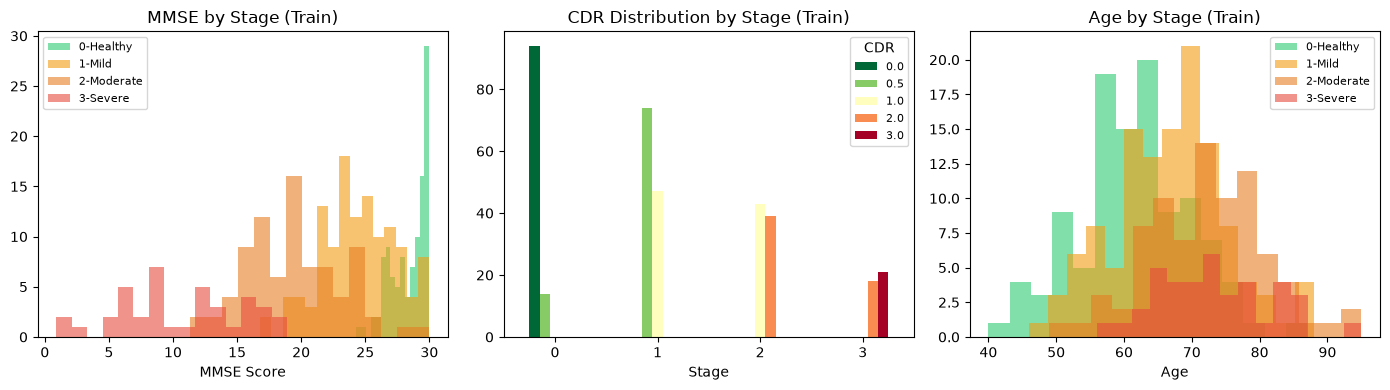

Plot saved.


In [12]:
# Quick visual: MMSE by stage (training only)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

stage_labels = ['0-Healthy', '1-Mild', '2-Moderate', '3-Severe']
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# MMSE distribution by stage
for stage in range(4):
    subset = df_train[df_train['stage'] == stage]['mmse']
    axes[0].hist(subset, alpha=0.6, label=stage_labels[stage], color=colors[stage], bins=15)
axes[0].set_title('MMSE by Stage (Train)')
axes[0].set_xlabel('MMSE Score')
axes[0].legend(fontsize=8)

# CDR distribution by stage
cdr_by_stage = df_train.groupby(['stage', 'cdr']).size().unstack(fill_value=0)
cdr_by_stage.plot(kind='bar', ax=axes[1], colormap='RdYlGn_r')
axes[1].set_title('CDR Distribution by Stage (Train)')
axes[1].set_xlabel('Stage')
axes[1].legend(title='CDR', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

# Age distribution by stage
for stage in range(4):
    subset = df_train[df_train['stage'] == stage]['age']
    axes[2].hist(subset, alpha=0.6, label=stage_labels[stage], color=colors[stage], bins=15)
axes[2].set_title('Age by Stage (Train)')
axes[2].set_xlabel('Age')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/day3_sanity_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [13]:
# Compute class frequencies (same concept as DL.AI Ex 2)
stage_counts = df_train['stage'].value_counts().sort_index()
N_train = len(df_train)

print('Class imbalance in training set:')
for stage, count in stage_counts.items():
    pct = count / N_train * 100
    bar = '█' * int(pct / 2)
    print(f'  Stage {stage} ({stage_labels[stage]:12s}): {count:4d} patients ({pct:.1f}%) {bar}')

print(f'\nNote: Stage 3 (Severe) is the minority class — {stage_counts[3]/N_train*100:.1f}% of training data.')
print('This is realistic. On Day 6, use class_weight in logistic regression to handle it.')

Class imbalance in training set:
  Stage 0 (0-Healthy   ):  108 patients (30.9%) ███████████████
  Stage 1 (1-Mild      ):  121 patients (34.6%) █████████████████
  Stage 2 (2-Moderate  ):   82 patients (23.4%) ███████████
  Stage 3 (3-Severe    ):   39 patients (11.1%) █████

Note: Stage 3 (Severe) is the minority class — 11.1% of training data.
This is realistic. On Day 6, use class_weight in logistic regression to handle it.


## 6. Save Splits to Disk

In [14]:
df_train.to_csv(f'{DATA_DIR}/train.csv', index=False)
df_val.to_csv(f'{DATA_DIR}/val.csv',     index=False)
df_test.to_csv(f'{DATA_DIR}/test.csv',   index=False)

print('Saved:')
print(f'  data/train.csv — {len(df_train)} rows')
print(f'  data/val.csv   — {len(df_val)} rows')
print(f'  data/test.csv  — {len(df_test)} rows')
print()
print('Columns:', list(df_train.columns))

Saved:
  data/train.csv — 350 rows
  data/val.csv   — 75 rows
  data/test.csv  — 75 rows

Columns: ['patient_id', 'stage', 'age', 'sex', 'bmi', 'years_education', 'family_history', 'depression', 'sleep_disorder', 'constipation', 'mmse', 'cdr', 'tremor', 'rigidity', 'bradykinesia', 'postural_instability', 'speech_problems']


## 7. Day 3 Reflection

Write your reflection in `notes/day3_reflection.md`. Template below:

```
## Day 3 Reflection — July 2, 2026

### What I built
- 500-patient synthetic dataset with 17 features across demographics, cognitive assessments, motor symptoms, and clinical history
- Stratified 70/15/15 train/val/test split
- Verified zero patient overlap (no leakage)

### Clinical features I now understand
- MMSE: [write what you noticed about the distributions]
- CDR: [write what the 0/0.5/1/2/3 scale felt like in the data]
- Tremor/bradykinesia: [what did the 0–4 scale reveal about stage progression?]

### Class imbalance note
- Stage 3 is underrepresented (~10%). On Day 6 I will use class_weight='balanced' in logistic regression.
- DL.AI parallel: same problem as ChestX-ray8 where Hernia was <1% of cases.

### What surprised me

### What I want to verify on Day 4 (distribution exploration)
```

---
**Day 3 complete.** Next: Day 4 — explore distributions, write full reflection note.

*Movement break before closing the session.*